# Experiment Prototype Title

In [67]:
# Import my custom code from the editable package in sitnikov/src
from src.integrator.integrate import *

#Import other libraries
import numpy as np
import matplotlib.pyplot as plt
import rebound
from scipy.optimize import brentq

In [68]:
# Low compute and simplest parameters to test my boundary computations
dv = 1e-1
N_t = 20
e = 0.5

In [69]:
z0 = (np.sqrt(2)/4 * e / dv)**(2/5)
r_2 = 1/2* (1 + e)
v2 = np.sqrt(2/np.sqrt(z0**2 + r_2**2))

# We store the points in a list
# First the inner boundary (B2) inside of which we have certain return
B2 = []

for t in np.linspace(0, 2*np.pi, N_t, endpoint=False):
    # We initialize with negative velocity at negative time to integrate backwards
    sim = initialize_simulation(e = e, z = z0, z_dot = -v2, t = -t)
    
    # Now we integrate until we have intersection with z = 0
    dt = 0.1 # Initial timestep where we look for intersection with z = 0

    sim_prev = sim.copy()
    sim.integrate(sim.t + dt)

    while sim.particles[2].z > 0:
        sim_prev = sim.copy()
        sim.integrate(sim.t + dt)

    # Now we have that the crossing occurs between sim_prev.t and sim.t,
    # so we refine with brentq    

    def z_func(t):
        sim_loc = sim_prev.copy()
        sim_loc.integrate(t, exact_finish_time=1)
        return sim_loc.particles[2].z
    
    t_cross = brentq(z_func, sim_prev.t, sim_prev.t + dt, xtol = 1e-14)

    sim_prev.integrate(t_cross)
    v_final = sim_prev.particles[2].vz

    # We change signs again to the final backwards-integrated values
    B2.append(np.array([-v_final, (-t_cross) % (2*np.pi)]))

In [70]:
B2_v_arr = np.zeros(N_t)
B2_t_arr = np.zeros(N_t)

for i in range(N_t):
    v = B2[i][0]
    t = B2[i][1]
    B2_v_arr[i] = v
    B2_t_arr[i] = t 

#### Remarkably, the points after backward integration seem to have equally spaced t values

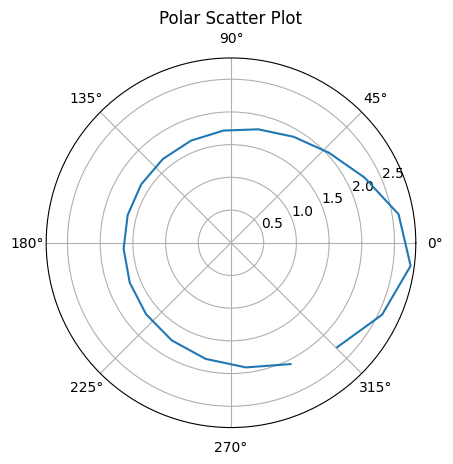

In [71]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(B2_t_arr, B2_v_arr)
ax.set_title("Polar Scatter Plot")
plt.show()

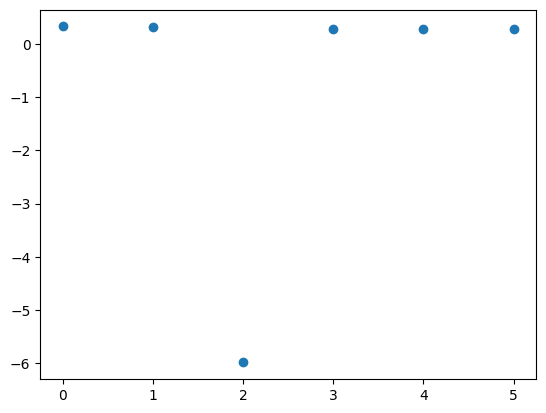

In [72]:
fig, ax = plt.subplots()
ax.scatter(np.arange(N_t//3), np.array([B2_t_arr[i+1] - B2_t_arr[i] for i in range(N_t//3)]))

So it seems that points in the boundary are not equally spaced, but they are closed to equally spaced. I just realized you can mathematically justify that the points with larger t at z = z0 must have larger t at z = 0 (integrating backward). There is a monotonicity argument by moving all points to the same t, with the appropriate z, v.

In [73]:
print(z0)

1.25594321575479


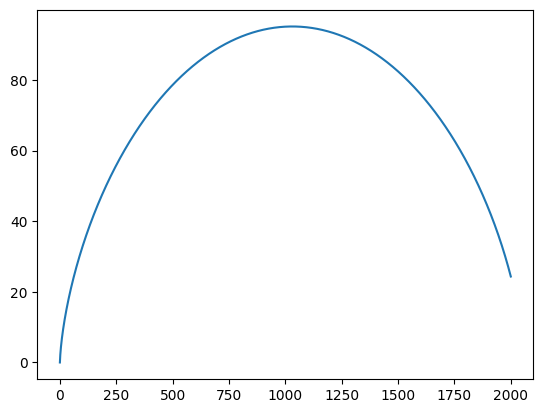

2.2525852735127616 1.6510432464255203


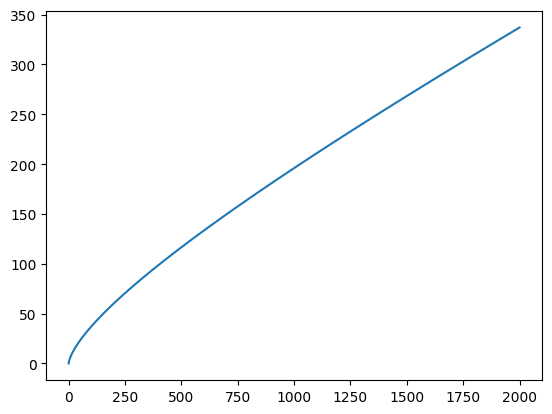

In [81]:
# Briefly test how good these estimates are.
# The actual value of dv is actually much smaller (<1e-2 instead of 1e-1)
j = 10
vi = B2_v_arr[j]
ti = B2_t_arr[j]

from src.utils.plotting import plot_position_sitnikov

# Orbit of B2
print("We have return at B2")
plot_position_sitnikov(T = 2000, dt = 0.1, e = e, t = ti, v = vi)
print(ti, vi)

# Orbit of B2 + dv
print("We don't have return at B2 + dv")
plot_position_sitnikov(T = 2000, dt = 0.1, e = e, t = ti, v = vi + 0.01)


In [ ]:
def returns(e, z, v, t, Tmax):
    """
    Returns True if the point particle returns to z=0 for the given 
    parameters (e, z, v, t) within time Tmax.
    """
    sim = initialize_simulation(e, z, v, t)
    t_start = sim.t
    
    # Coarse search parameters
    r_min = 0.5 * (1 - e)
    # Ensure dt is small enough to not skip z=0 crossings
    dt = 0.1
    if v > 0:
        dt = min(dt, 2 * v * r_min**2)
    elif v < 0:
        dt = min(dt, 2 * abs(v) * r_min**2)

    while sim.t < t_start + Tmax:
        z_prev = sim.particles[2].z
        sim.integrate(sim.t + dt)
        z_curr = sim.particles[2].z
        
        # Check for crossing z=0 (sign change)
        if z_prev * z_curr <= 0:
            return True
            
    return False

In [ ]:
# We use the given values of z0, v2 (dv = 1e-1)
# We can confidently say that return always happens in less than 4000, 
# but return times can be upwards of 2000

for t in np.linspace(0, 2*np.pi, 20, endpoint=False):
    if not returns(e, z0, v2, t, Tmax = 4000):
        print("Non-return detected for t = {0}".format(t))

In [ ]:
# Again, an extensive search shows that all particles return in at most 4000. The minimum return time is around 90 though.
for t, v in zip(B2_t_arr, B2_v_arr):
    print(phi(e, v, t, t_max = 4000))

(2.115324356041022, 107.84291979521711)
(1.73993207158948, 134.0843113742257)
(1.6495353807823165, 185.05307709316207)
(1.7993899307265158, 272.1023588571541)
(2.3000470710092134, 446.8807119202833)
(1.850610954055011, 787.1626505061097)
(2.067524458456539, 1452.5924146716695)
(1.6409522025234375, 2579.7189860267704)
(1.712549697657125, 3602.7752682927317)
(2.425139807977574, 3248.080801942438)
(1.6447112719196348, 2064.2162662475703)
(2.632404174472534, 1169.0547562944062)
(1.6656243197772145, 675.1651295474423)
(2.618972533037786, 414.536045410275)
(1.6934227084841234, 272.68971857094215)
(1.6194112800835494, 191.84769941219403)
(2.370008159104961, 144.16240660218622)
(1.60906595813117, 116.37750376432479)
(2.025143770538055, 101.73102706412364)
(1.6323047757044917, 98.59819127422959)


We see a big spread, from a minimum of around 90 return time to a maximum of around 3600 return time, so more than an order of magnitude difference.

In [83]:
import numpy as np
import os

# Define the path to the previous experimental data
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../initial_exploration/boundary_test1/e0_5__v2_eps0_001__deltmax_100.npy"))

# Load the file
v2_data = np.load(data_path)
print(f"Loaded data from {data_path}")
print(f"Data shape: {v2_data.shape}")


Loaded data from c:\Users\leona\Documents\CelestialMechanics\sitnikov\initial_exploration\boundary_test1\e0_5__v2_eps0_001__deltmax_100.npy
Data shape: (2, 100)


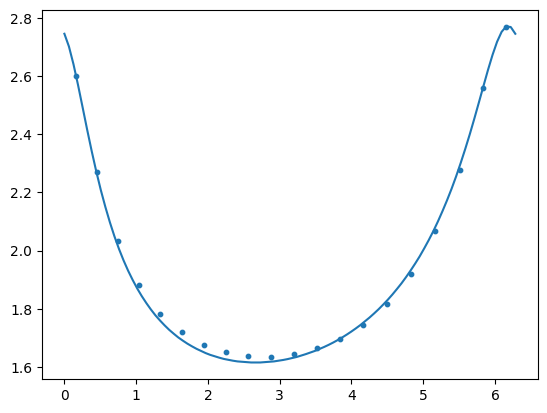

In [ ]:
fig, ax = plt.subplots()
ax.scatter(B2_t_arr, B2_v_arr, s = 10)
ax.plot(v2_data[0], v2_data[1])

We can see a general qualitative agreement, but the difference is significant. This is due to the different escape times of both curves. Nevertheless, we can conclude the previous estimate was significantly further from the true boundary than the choice eps = 1e-3 suggests was desired. 

#### Overall, the method seems very effective and computationally cheap, but note the big spread in actual return time

## Computing the outer boundary B1

In [100]:
# We use the same e, dv, N_t parameters as before
z0 = (np.sqrt(2)/4 * e / dv)**(2/5)
r_1 = 1/2* (1 - e)
v1 = np.sqrt(2/np.sqrt(z0**2 + r_1**2))

# We store the points in a list
# First the inner boundary (B2) inside of which we have certain return
B1 = []

for t in np.linspace(0, 2*np.pi, N_t, endpoint=False):
    # We initialize with negative velocity at negative time to integrate backwards
    sim = initialize_simulation(e = e, z = z0, z_dot = -v1, t = -t)
    
    # Now we integrate until we have intersection with z = 0
    dt = 0.1 # Initial timestep where we look for intersection with z = 0

    sim_prev = sim.copy()
    sim.integrate(sim.t + dt)

    while sim.particles[2].z > 0:
        sim_prev = sim.copy()
        sim.integrate(sim.t + dt)

    # Now we have that the crossing occurs between sim_prev.t and sim.t,
    # so we refine with brentq    

    def z_func(t):
        sim_loc = sim_prev.copy()
        sim_loc.integrate(t, exact_finish_time=1)
        return sim_loc.particles[2].z
    
    t_cross = brentq(z_func, sim_prev.t, sim_prev.t + dt, xtol = 1e-14)

    sim_prev.integrate(t_cross)
    v_final = sim_prev.particles[2].vz

    # We change signs again to the final backwards-integrated values
    B1.append(np.array([-v_final, (-t_cross) % (2*np.pi)]))

In [101]:
B1_t_arr = np.array([x[1] for x in B1])
B1_v_arr = np.array(x[0] for x in B1)

In [ ]:
fig, ax = plt.subplots(subplot_kw=
ax.